# View Train Data

In [1]:
import pickle

import os
import json
import pickle

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from networks import PrimalNetEndToEnd  # make sure this is importable
# from gep_config_parser import parse_config  # only if you really need it

from gep_config_parser import parse_config

In [2]:
data_path = f"data/GEP_data/sample_duration:876_N:B-G-F_G:B2-G2-F2_L:L3.pkl"
data = pickle.load(open(data_path, 'rb'))

input_data = parse_config("configs/config.toml") # Reads the input data using config.toml's experiment.inputs.data path.

gep_ed_data = input_data["experiment"]["experiments"][0]

In [4]:
gep_ed_data

{'representative_period_weight': 1,
 'value_of_lost_load': 10.0,
 'ramping_value': 0.2,
 'demand_data':        Country  Time     Demand_MW
 0          AUS     1   4464.841992
 1          AUS     2   4124.826130
 2          AUS     3   3816.906161
 3          AUS     4   3526.037135
 4          AUS     5   3444.794407
 ...        ...   ...           ...
 175195     UKI  8756  35530.306849
 175196     UKI  8757  32133.512065
 175197     UKI  8758  28620.704825
 175198     UKI  8759  25327.448038
 175199     UKI  8760  23188.078573
 
 [175200 rows x 3 columns],
 'generation_data':     Technology Country  InvCost_kEUR_MW_year  VarCost_kEUR_per_MWh  UnitCap_MW
 0         Coal     BLK                 33.75                0.1500         400
 1         Coal     CZE                 33.75                0.1500         400
 2         Coal     GER                 33.75                0.1500         400
 3         Coal     IRE                 33.75                0.1500         400
 4         Coal 

In [5]:


countries = ["GER", "BEL", "FRA"]
dem = gep_ed_data["demand_data"]
ava = gep_ed_data["generation_availability_data"]

dem3 = dem[dem["Country"].isin(countries)]
ava3 = ava[ava["Country"].isin(countries)].copy()

# What you asked for: mean/std
dem_stats = dem3.groupby("Country")["Demand_MW"].agg(["mean","std","min","max"])
ava_stats = ava3.groupby(["Country","Technology"])["Availability_pu"].agg(
    ["mean","std","min","max", ("zero_frac", lambda s: (s <= 1e-6).mean())])
print("DEMAND (MW):\n", dem_stats, "\n")
print("AVAILABILITY (pu):\n", ava_stats, "\n")

# The two diagnostics that decide whether Gaussian sampling is even valid:
dem_w = dem3.pivot(index="Time", columns="Country", values="Demand_MW")
dem_w.columns = [f"D_{c}" for c in dem_w.columns]
ava3["var"] = "A_" + ava3["Country"] + "_" + ava3["Technology"]
ava_w = ava3.pivot(index="Time", columns="var", values="Availability_pu")
joint = dem_w.join(ava_w, how="inner")
print("Cross-correlation of the joint (D,A) vector:\n", joint.corr().round(2))

DEMAND (MW):
                  mean           std           min           max
Country                                                        
BEL       5608.193157   1336.536030   2403.698760   8890.113738
FRA      33967.269036  11683.933037   9494.393648  71931.625840
GER      43911.986410  11190.563663  19294.266848  67462.984974 

AVAILABILITY (pu):
                         mean       std    min    max  zero_frac
Country Technology                                             
BEL     SunPV       0.124312  0.195611  0.000  0.833   0.497374
        WindOff     0.540528  0.247773  0.000  0.991   0.008333
        WindOn      0.297726  0.220202  0.000  0.974   0.000799
FRA     SunPV       0.146185  0.202664  0.000  0.815   0.468721
        WindOff     0.481749  0.277990  0.000  0.991   0.004909
        WindOn      0.286956  0.168061  0.014  0.918   0.000000
GER     SunPV       0.122620  0.182642  0.000  0.813   0.482420
        WindOff     0.503661  0.275089  0.000  0.992   0.001712
    

## CHECK the GEP to obtain Training Data

In [1]:
import pickle, os, glob
import numpy as np
import pandas as pd

DIR = "data/GEP_for_training"

# --- load manifest + all instances ---
with open(os.path.join(DIR, "manifest.pkl"), "rb") as f:
    manifest = pickle.load(f)

paths = sorted(glob.glob(os.path.join(DIR, "gep_instance_*.pkl")))
instances = []
for p in paths:
    with open(p, "rb") as f:
        instances.append(pickle.load(f))
print(f"Loaded {len(instances)} instances\n")

# --- what attributes does a GEPProblemSet actually expose? (run once) ---
print("Attributes on instance 0:")
print([a for a in vars(instances[0]).keys() if not a.startswith("_")])
print()

Loaded 14 instances

Attributes on instance 0:
['DTYPE', 'DEVICE', 'args', 'sample_duration', 'T', 'G', 'L', 'N', 'num_g', 'num_l', 'num_n', 'pDemand', 'pGenAva', 'pVOLL', 'pWeight', 'pRamping', 'pInvCost', 'pVarCost', 'pUnitCap', 'pExpCap', 'pImpCap', 'n_var_per_t', 'n_ineq_per_t', 'n_eq_per_t', 'time_ranges', 'n_inv_vars', 'n_prod_vars', 'n_line_vars', 'n_md_vars', 'neq', 'nineq', 'ydim', 'node_to_gen_mask', 'lineflow_mask', 'obj_coeff', 'eq_rhs', 'ineq_rhs', 'X', 'xdim']



In [2]:
# --- 1. Manifest overview: the regime knobs per instance ---
rows = []
for m in manifest:
    rows.append({
        "id": m["instance_id"],
        "horizon": m["horizon"],
        "demand_scale": m["demand_scale"],
        "node_mult": str(m["node_multipliers"]),
        "cinv_perturb": m["cinv_perturb"],
        "n_unique_hours": len(set(m["drawn_hours"])),   # <876 => draw-with-replacement collisions
    })
manifest_df = pd.DataFrame(rows)
print("REGIME MANIFEST"); print(manifest_df.to_string(index=False), "\n")

# --- 2. Did the demand transforms land? mean nodal demand per instance ---
def nodal_mean_demand(inst):
    N = inst.N
    # pDemand keyed (country, time); average over time per node
    out = {n: np.mean([v for (c, t), v in inst.pDemand.items() if c == n]) for n in N}
    return out

dem_rows = []
for i, inst in enumerate(instances):
    d = nodal_mean_demand(inst)
    d = {"id": i, **{f"D_{k}": round(v, 0) for k, v in d.items()},
         "total": round(sum(d.values()), 0)}
    dem_rows.append(d)
print("MEAN NODAL DEMAND (MW) — check scale/spatial regimes moved it")
print(pd.DataFrame(dem_rows).to_string(index=False), "\n")

# --- 3. Did C^inv perturbation land? recovered factors from manifest ---
print("C^inv PERTURBATION FACTORS (should differ per instance, within ±0.3)")
for m in manifest:
    print(f"  inst {m['instance_id']}: {({k: round(v,2) for k,v in m['cinv_factors'].items()})}")
print()

REGIME MANIFEST
 id  horizon  demand_scale                            node_mult  cinv_perturb  n_unique_hours
  0      219          0.50                                 None           0.5             218
  1      219          0.70                                 None           0.3             216
  2      219          0.85                                 None           0.3             216
  3      219          1.00                                 None           0.3             217
  4      219          1.15                                 None           0.3             217
  5      219          1.30                                 None           0.3             217
  6      219          1.50                                 None           0.5             218
  7      219          1.00 {'FRA': 1.4, 'GER': 0.8, 'BEL': 0.8}           0.3             215
  8      219          1.00 {'GER': 1.4, 'FRA': 0.8, 'BEL': 0.8}           0.3             215
  9      219          1.15 {'BEL': 1.5, 'GER

In [3]:
args = json.load(open("configs/config.json", "r"))
# --- 4. Structural summary per instance ---
def struct_summary(inst, i):
    return {
        "id": i,
        "|T|": len(inst.T),
        "|G|": inst.num_g, "|L|": inst.num_l, "|N|": inst.num_n,
        "ydim": getattr(inst, "ydim", None),
        "neq": getattr(inst, "neq", None),
        "nineq": getattr(inst, "nineq", None),
        "pVOLL": getattr(inst, "pVOLL", None),
    }
print("STRUCTURE (should be identical across instances except values)")
print(pd.DataFrame([struct_summary(inst, i) for i, inst in enumerate(instances)]).to_string(index=False), "\n")

# --- 5. Availability sanity: solar should still be ~50% zeros, all in [0,1] ---
inst = instances[0]
ava_vals = np.array(list(inst.pGenAva.values()))
print(f"Availability across instance 0: min={ava_vals.min():.3f} max={ava_vals.max():.3f} "
      f"zero_frac={np.mean(ava_vals <= 1e-6):.3f}  (expect max<=1, solar zeros present)\n")

# --- 6. C^inv actually differs between two instances (reads the built object) ---
print("pInvCost, instance 0 vs 1 (should differ per generator):")
for g in [tuple(x) for x in args["Benders_args"]["G"]]:
    v0 = instances[0].pInvCost.get(g); v1 = instances[1].pInvCost.get(g)
    print(f"  {g}: {v0:.2f}  vs  {v1:.2f}")

NameError: name 'json' is not defined

## Solve GEP to get train data

ed_gen_data.X:[191051,9] for no PER BIN CAP
WITH PER BIN CAP 188777


In [78]:
ed_gen_path = "data/ED_data_gen/harvested_training_data_cluster_inv.pkl"

# harvested_training_data_perturb

ed_gen_path = "data/ED_data_gen/harvested_training_data_perturb.pkl"
ed_gen_path = "data/ED_data_gen/harvested_training_data_perturb_full.pkl"
ed_gen_data = pickle.load(open(ed_gen_path, 'rb'))


In [79]:
ed_gen_data.X.shape

torch.Size([37944, 9])

 SUM |iter|*#sub

In [80]:
X = ed_gen_data.X
D = X[:, :3]                                   # demand columns

print("total states:", X.shape[0])
print("unique demand triples:", torch.unique(D, dim=0).shape[0])
# expect: roughly (#distinct drawn hours) x (#distinct demand-transform settings),
# NOT 1, and NOT equal to total states

# does demand actually span the regimes? total system demand per row:
tot = D.sum(dim=1)
print("total-demand  min/mean/max:", float(tot.min()), float(tot.mean()), float(tot.max()))
# min should reflect your 0.5x regime, max your 1.5x regime — a wide range

total states: 37944
unique demand triples: 4743
total-demand  min/mean/max: 19922.334347573935 88511.80332278574 197585.1173438682


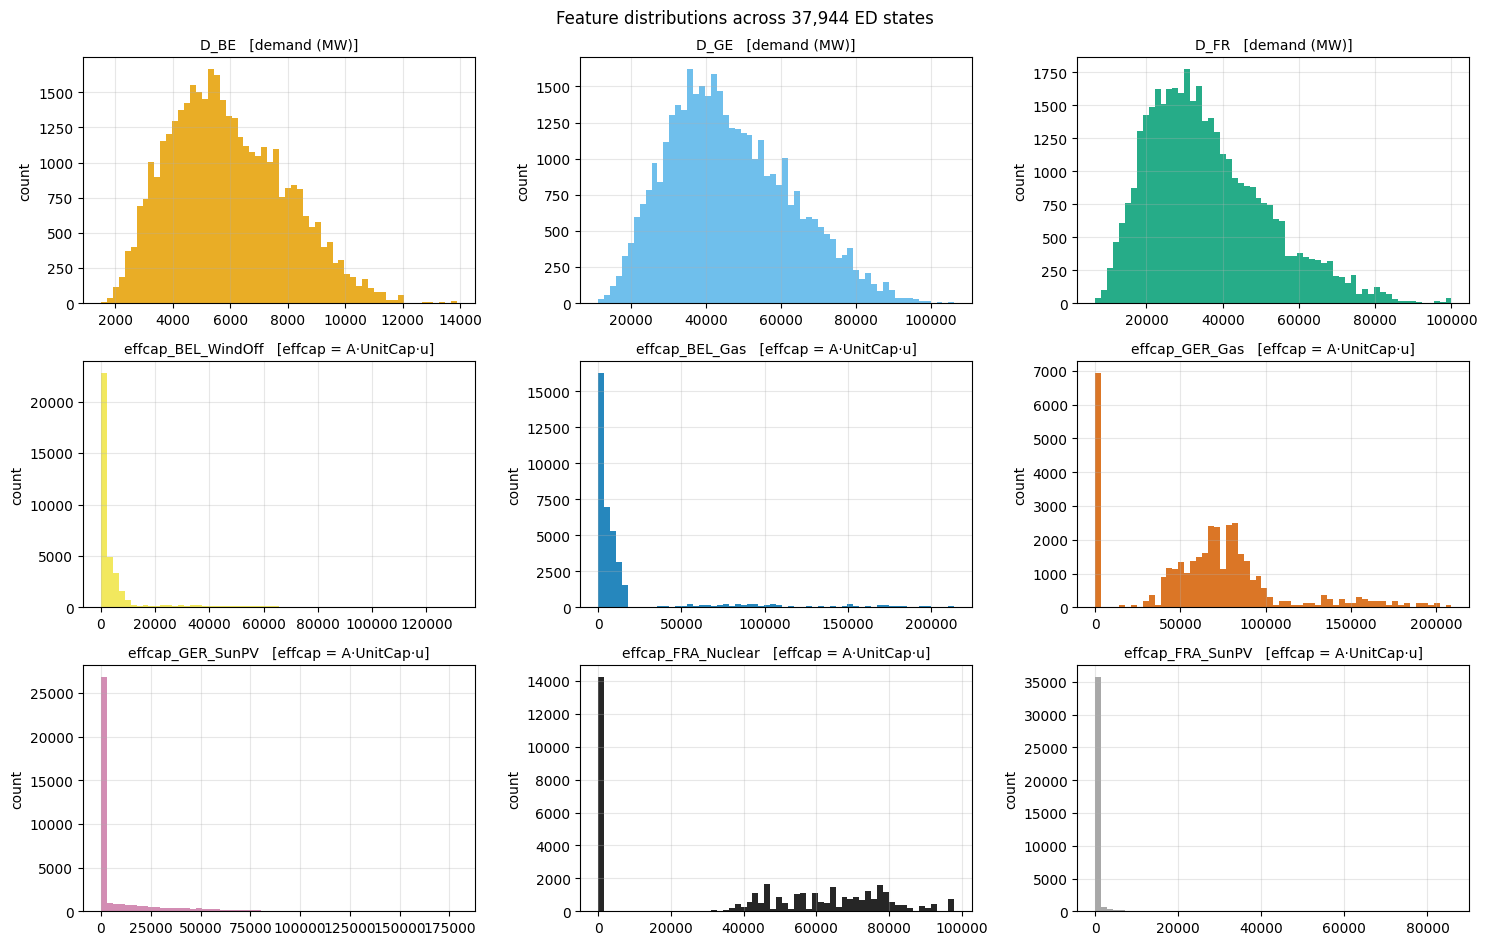

In [81]:
import matplotlib.pyplot as plt
import numpy as np, torch

X = ed_gen_data.X.numpy() if torch.is_tensor(ed_gen_data.X) else np.asarray(ed_gen_data.X)
G_names = [f"{c}_{t}" for (c, t) in ed_gen_data.G]
col_names = ["D_BE", "D_GE", "D_FR"] + [f"effcap_{g}" for g in G_names]

OKABE_ITO = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
             "#0072B2", "#D55E00", "#CC79A7", "#000000", "#999999"]

ncol = 3
nrow = int(np.ceil(X.shape[1] / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 3.2 * nrow))
axes = axes.ravel()

for j in range(X.shape[1]):
    ax = axes[j]
    ax.hist(X[:, j], bins=60, color=OKABE_ITO[j % len(OKABE_ITO)], alpha=0.85)
    kind = "demand (MW)" if j < 3 else "effcap = A·UnitCap·u"
    ax.set_title(f"{col_names[j]}   [{kind}]", fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylabel("count")

for k in range(X.shape[1], len(axes)):
    fig.delaxes(axes[k])

fig.suptitle(f"Feature distributions across {X.shape[0]:,} ED states", fontsize=12)
fig.tight_layout()
plt.show()

In [82]:
col = 8  # FRA_SunPV effcap
nz = X[:, col] > 1e-6
print("nonzero fraction:", nz.mean())
print("nonzero count:", nz.sum())
if nz.any():
    print("nonzero min/max/std:", X[nz, col].min(), X[nz, col].max(), X[nz, col].std())
else:
    print("no nonzero values at all")

nonzero fraction: 0.1757853679106051
nonzero count: 6670
nonzero min/max/std: 0.030135846475870663 85779.11828217603 7975.891810221246


In [83]:
X = ed_gen_data.X.numpy() if torch.is_tensor(ed_gen_data.X) else np.asarray(ed_gen_data.X)
D = X[:, :3]
print("unique demand triples:", np.unique(D, axis=0).shape[0])
print("demand per-node std/mean:", (D.std(0)/D.mean(0)).round(2))

unique demand triples: 4743
demand per-node std/mean: [0.34 0.35 0.43]


In [84]:
G_names = [f"{c}_{t}" for (c,t) in ed_gen_data.G]
E = X[:, 3:]
for j, name in enumerate(G_names):
    col = E[:, j]
    nz = col > 1e-6
    print(f"{name:<14} nonzero {nz.mean():5.1%}  "
          f"std/mean {col.std()/(col.mean()+1e-9):4.1f}  "
          f"range [{col.min():.0f}, {col[nz].max() if nz.any() else 0:.0f}]")

BEL_WindOff    nonzero 49.7%  std/mean  2.4  range [-0, 131397]
BEL_Gas        nonzero 66.4%  std/mean  2.2  range [-0, 214000]
GER_Gas        nonzero 81.7%  std/mean  0.7  range [-0, 209000]
GER_SunPV      nonzero 32.0%  std/mean  2.1  range [-0, 178904]
FRA_Nuclear    nonzero 62.5%  std/mean  0.8  range [-0, 98000]
FRA_SunPV      nonzero 17.6%  std/mean  6.0  range [-0, 85779]


dims for 90% variance: 6 of 9
explained variance ratio: [0.31 0.2  0.13 0.11 0.09 0.07 0.05 0.03 0.01]


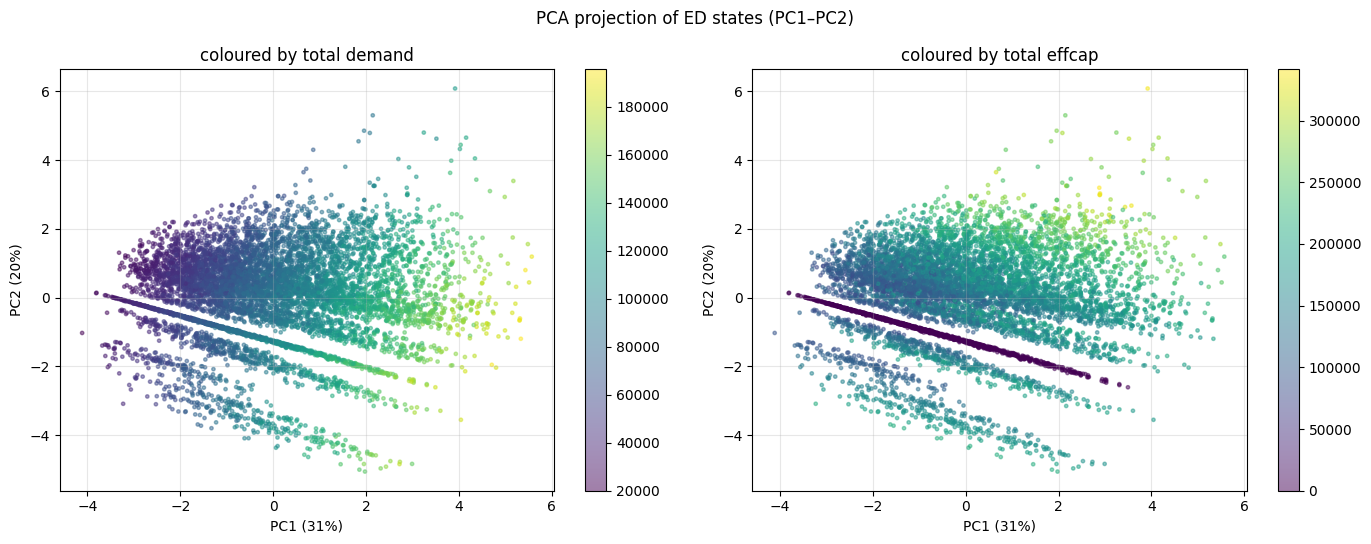

In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
Xz = StandardScaler().fit_transform(X)
pca = PCA().fit(Xz)
cum = np.cumsum(pca.explained_variance_ratio_)
print("dims for 90% variance:", np.argmax(cum >= 0.90) + 1, "of", X.shape[1])
print("explained variance ratio:", pca.explained_variance_ratio_.round(2))
Z   = pca.transform(Xz)                       # projected coords

# colour variables
tot_demand = X[:, :3].sum(1)                  # operational axis
tot_effcap = X[:, 3:].sum(1)                  # investment axis

# subsample for plotting if large (scatter of 30k+ is slow and overplotted)
n = X.shape[0]
idx = np.random.default_rng(0).choice(n, size=min(8000, n), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, c, title in [(axes[0], tot_demand[idx], "coloured by total demand"),
                     (axes[1], tot_effcap[idx], "coloured by total effcap")]:
    sc = ax.scatter(Z[idx, 0], Z[idx, 1], c=c, s=6, alpha=0.5, cmap="viridis")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.0%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
    ax.set_title(title); ax.grid(alpha=0.3)
    fig.colorbar(sc, ax=ax)
fig.suptitle("PCA projection of ED states (PC1–PC2)")
fig.tight_layout(); plt.show()

In [86]:
for j, name in enumerate(["BEL_WindOff","BEL_Gas","GER_Gas","GER_SunPV","FRA_Nuclear","FRA_SunPV"]):
    col = X[:, 3+j]; nz = col > 1e-6
    mid = (col > 0.2*col[nz].max()) & (col < 0.8*col[nz].max()) if nz.any() else nz
    print(f"{name:<12} nonzero {nz.mean():5.1%}  mid-range {mid.mean():5.1%}")

BEL_WindOff  nonzero 49.7%  mid-range  8.7%
BEL_Gas      nonzero 66.4%  mid-range 10.5%
GER_Gas      nonzero 81.7%  mid-range 74.7%
GER_SunPV    nonzero 32.0%  mid-range 10.9%
FRA_Nuclear  nonzero 62.5%  mid-range 50.8%
FRA_SunPV    nonzero 17.6%  mid-range  0.9%


In [163]:
import os, glob, ast
import numpy as np
import pandas as pd
import torch

CSV_DIR = "outputs/Benders/3Node/Sample_219/iter_logs_Inexact_Refine_Benders_perturb_NoClassFull_full"  # adjust

# ---- training data ----
X = ed_gen_data.X.numpy() if torch.is_tensor(ed_gen_data.X) else np.asarray(ed_gen_data.X)
train_effcap = X[:, 3:]                                  # [Ntrain, 6]
G = [tuple(g) for g in ed_gen_data.G]
G_names = [f"{c}_{t}" for (c, t) in G]
unitcap = np.array([ed_gen_data.pUnitCap[g] for g in G])  # [6]

# ---- helper: parse the investment column "[0.0, 405.0, ...]" -> array ----
def parse_u(s):
    return np.array(ast.literal_eval(s), dtype=float)

# ---- load all deployment investments, tagged by sample ----
rows = []
for path in sorted(glob.glob(os.path.join(CSV_DIR, "*.csv"))):
    df = pd.read_csv(path)
    df = df[df["exact_mode"] == False]
    sample = os.path.basename(path).split("sample")[1].split("_")[0]
    U = np.vstack(df["investment"].apply(parse_u).values)   # [n_iter, 6]
    for it, u in enumerate(U):
        rows.append({"sample": sample, "iter": it, "u": u, "gap_rel": df["gap_rel"].iloc[it]})

print(f"loaded {len(rows)} deployment inexact investments from {CSV_DIR}")

# ---- convert deployment u -> effcap is hour-dependent for renewables.
# Simplest faithful comparison: compare in effcap space using MEAN availability
# per generator from the training data (so renewables get a representative A).
# For dispatchables A=1 so this is exact; for renewables it's an approximation.
# We recover per-generator mean A from training: effcap = A*unitcap*u
# But we don't have u in training. Instead compare deployment u mapped through
# unitcap only (A=1 assumption) for dispatchables, and flag renewables separately.

# Identify renewables vs dispatchables
renew_techs = {"WindOff", "WindOn", "SunPV"}
is_renew = np.array([t in renew_techs for (_, t) in G])

# deployment "max effcap" = unitcap * u  (A=1 upper bound; exact for dispatchables)
def u_to_maxeffcap(u):
    return unitcap * u

# training max effcap per row is not directly available (A folded in),
# so for the coverage check use the cleanest exact channel: DISPATCHABLES.
# For dispatchables, training effcap = 1*unitcap*u_train, so train_u = effcap/unitcap.
disp_idx = np.where(~is_renew)[0]
train_u_disp = train_effcap[:, disp_idx] / unitcap[disp_idx]      # [Ntrain, n_disp] exact
train_u_disp_unique = np.unique(np.round(train_u_disp, 1), axis=0)

# ---- nearest-neighbour distance: each deployment u (dispatchables) vs training ----
from scipy.spatial import cKDTree
tree = cKDTree(train_u_disp_unique)

dep_u_disp = np.vstack([r["u"][disp_idx] for r in rows])         # [Ndep, n_disp]
dists, _ = tree.query(dep_u_disp, k=1)

for r, d in zip(rows, dists):
    r["nn_dist"] = d

res = pd.DataFrame([{"sample": r["sample"], "iter": r["iter"],
                     "gap_rel": r["gap_rel"], "nn_dist": r["nn_dist"]} for r in rows])

print("\n=== dispatchable-investment coverage (deployment vs training) ===")
print(f"generators compared: {[G_names[i] for i in disp_idx]}")
print(res["nn_dist"].describe().round(2))

loaded 320 deployment inexact investments from outputs/Benders/3Node/Sample_219/iter_logs_Inexact_Refine_Benders_perturb_NoClassFull_full

=== dispatchable-investment coverage (deployment vs training) ===
generators compared: ['BEL_Gas', 'GER_Gas', 'FRA_Nuclear']
count    320.00
mean      20.05
std       30.36
min        0.00
25%        4.12
50%       13.58
75%       23.30
max      374.33
Name: nn_dist, dtype: float64


In [164]:
# 1. Early (overshoot) vs late iterations — are the wild early u far from training?
res["phase"] = np.where(res["iter"] < 3, "early(0-2)", "later")
print("\nNN distance by phase:")
print(res.groupby("phase")["nn_dist"].agg(["mean","median","max"]).round(1))

# 2. Per-generator gap — which dispatchable is most out-of-coverage?
print("\nper-dispatchable: fraction of deployment values with no near training match")
for k, gi in enumerate(disp_idx):
    col_tree = cKDTree(train_u_disp_unique[:, [k]])
    dd, _ = col_tree.query(dep_u_disp[:, [k]], k=1)
    # 'far' = beyond 1 unit from any trained value for that generator
    print(f"  {G_names[gi]:<12} far-fraction {np.mean(dd > 1.0):5.1%}  median gap {np.median(dd):.1f}")

# 3. THE MONEY PLOT: do bad-optimum samples visit more out-of-coverage investments?
# final gap per sample vs mean NN distance across its trajectory
per_sample = res.groupby("sample").agg(
    final_gap=("gap_rel", "last"),
    mean_nn_dist=("nn_dist", "mean"),
    max_nn_dist=("nn_dist", "max"),
).reset_index()
print("\nper-sample: final gap vs coverage distance")
print(per_sample.sort_values("final_gap", ascending=False).round(3).to_string(index=False))

corr = per_sample["final_gap"].corr(per_sample["mean_nn_dist"])
print(f"\ncorrelation(final_gap, mean_nn_dist) = {corr:.3f}")


NN distance by phase:
            mean  median    max
phase                          
early(0-2)  11.5     5.0   48.9
later       25.2    16.8  374.3

per-dispatchable: fraction of deployment values with no near training match
  BEL_Gas      far-fraction 11.6%  median gap 0.0
  GER_Gas      far-fraction  8.4%  median gap 0.0
  FRA_Nuclear  far-fraction 25.9%  median gap 0.0

per-sample: final gap vs coverage distance
sample  final_gap  mean_nn_dist  max_nn_dist
    28      0.985        23.755       39.674
    21      0.984        21.486       45.299
    25      0.984        21.678       48.918
    15      0.982        27.574       58.532
    14      0.977        20.807       47.508
    24      0.977        22.743       48.549
    29      0.973        18.886       40.200
    27      0.973        18.467       47.634
    26      0.971        19.281       43.046
    19      0.969        16.752       31.048
    17      0.965        18.359       40.112
    18      0.964        18.553       

In [165]:
import pickle, numpy as np
manifest = pickle.load(open("data/GEP_for_training_perturb_full/manifest.pkl","rb"))
bad = {14,15,25,26,28,21}; good = {0,36,9,7,3}
for m in manifest:
    i = m["instance_id"]
    if i in bad or i in good:
        tot = "?"  # or recompute mean total demand from the instance
        print(f"{'BAD ' if i in bad else 'good'} inst {i}: demand_scale={m['demand_scale']:.2f} "
              f"cinv={ {k:round(v,2) for k,v in m['cinv_factors'].items()} }")

good inst 0: demand_scale=1.22 cinv={'BEL_WindOff': 0.9, 'BEL_Gas': 1.24, 'GER_Gas': 1.0, 'GER_SunPV': 1.15, 'FRA_Nuclear': 1.05, 'FRA_SunPV': 1.12}
good inst 3: demand_scale=1.16 cinv={'BEL_WindOff': 1.22, 'BEL_Gas': 1.11, 'GER_Gas': 1.06, 'GER_SunPV': 1.01, 'FRA_Nuclear': 1.29, 'FRA_SunPV': 0.85}
good inst 7: demand_scale=1.23 cinv={'BEL_WindOff': 0.75, 'BEL_Gas': 0.9, 'GER_Gas': 1.08, 'GER_SunPV': 0.96, 'FRA_Nuclear': 1.28, 'FRA_SunPV': 0.98}
good inst 9: demand_scale=0.96 cinv={'BEL_WindOff': 1.2, 'BEL_Gas': 0.91, 'GER_Gas': 1.27, 'GER_SunPV': 1.0, 'FRA_Nuclear': 1.08, 'FRA_SunPV': 0.81}
BAD  inst 14: demand_scale=0.95 cinv={'BEL_WindOff': 1.02, 'BEL_Gas': 1.17, 'GER_Gas': 0.87, 'GER_SunPV': 1.27, 'FRA_Nuclear': 1.0, 'FRA_SunPV': 0.8}
BAD  inst 15: demand_scale=0.78 cinv={'BEL_WindOff': 1.16, 'BEL_Gas': 0.88, 'GER_Gas': 0.72, 'GER_SunPV': 0.96, 'FRA_Nuclear': 0.77, 'FRA_SunPV': 1.17}
BAD  inst 21: demand_scale=0.88 cinv={'BEL_WindOff': 1.26, 'BEL_Gas': 1.09, 'GER_Gas': 0.96, 'GER_S

In [166]:
# import os, glob
# import pandas as pd

EXACT_DIR = "outputs/Benders/3Node/Sample_219/iter_logs_Exact_Exact_full"  # adjust

# bad  = {14, 15, 21, 25, 26, 28}     # low-demand failures
# good = {0, 3, 7, 9, 36}             # high-demand successes

# def sample_id(path):
#     return int(os.path.basename(path).split("sample")[1].split("_")[0])

# rows = []
# for path in sorted(glob.glob(os.path.join(EXACT_DIR, "*.csv"))):
#     sid = sample_id(path)
#     if sid not in bad and sid not in good:
#         continue
#     df = pd.read_csv(path)
#     rows.append({
#         "sample": sid,
#         "group": "BAD(low-dem)" if sid in bad else "good(high-dem)",
#         "exact_iters": len(df),                         # rows = iterations to converge
#         "final_gap": df["gap_rel"].iloc[-1],
#     })

# r = pd.DataFrame(rows).sort_values(["group", "exact_iters"])
# print(r.to_string(index=False))
# print("\nmean exact iterations:")
# print(r.groupby("group")["exact_iters"].agg(["mean", "min", "max"]).round(1))

In [167]:
gep_path = "data/GEP_data/sample_duration:219_N:B-G-F_G:B2-G2-F2_L:L3.pkl"

gep_data = pickle.load(open(gep_path, 'rb'))

In [168]:
# import numpy as np, torch

# BAD  = [14, 15, 21, 25, 26, 28]
# GOOD = [0, 3, 7, 9, 36]

# def fingerprint(gep_data, s):
#     ineq_cm, ineq_rhs, eq_cm, eq_rhs = gep_data.get_sample_matrices(s)
#     ineq_rhs = ineq_rhs.numpy() if torch.is_tensor(ineq_rhs) else np.asarray(ineq_rhs)
#     eq_rhs   = eq_rhs.numpy()   if torch.is_tensor(eq_rhs)   else np.asarray(eq_rhs)

#     hours = list(gep_data.time_ranges[s])
#     N = gep_data.N
#     tot_dem = np.mean([sum(gep_data.pDemand[(n,t)] for n in N) for t in hours])

#     # the ineq RHS encodes capacity upper bounds (A*UnitCap*u) and line/unmet bounds.
#     # capacity_ub_indices marks the p <= A*Pmax*u rows — those are the ones that go
#     # slack when demand is low. Use them if available.
#     cap_idx = getattr(gep_data, "capacity_ub_indices", None)
#     cap_rhs = ineq_rhs[cap_idx] if cap_idx is not None else ineq_rhs

#     return {
#         "sample": s,
#         "mean_total_demand": tot_dem,
#         "eq_rhs_mean": np.abs(eq_rhs).mean(),          # power-balance RHS = demand
#         "cap_rhs_mean": cap_rhs.mean(),                # available capacity headroom
#         # the KEY ratio: capacity headroom vs demand. High = slack system = sparse duals
#         "capacity_slack_ratio": cap_rhs.mean() / (np.abs(eq_rhs).mean() + 1e-9),
#         "cap_rhs_zero_frac": np.mean(cap_rhs < 1e-6),  # fraction of gens with ~0 available cap
#     }

# import pandas as pd
# rows = [fingerprint(gep_data, s) for s in BAD + GOOD]
# df = pd.DataFrame(rows)
# df["group"] = ["BAD"]*len(BAD) + ["GOOD"]*len(GOOD)
# print(df.round(3).to_string(index=False))
# print("\ngroup means:")
# print(df.groupby("group")[["mean_total_demand","capacity_slack_ratio","cap_rhs_zero_frac"]].mean().round(3))

In [169]:
X = ed_gen_data.X.numpy()
tot = X[:, :3].sum(1)
print("training total-demand percentiles:", np.percentile(tot, [5,25,50,75,95]).round(0))
print("frac of training states below 69k (BAD level):", (tot < 69000).mean())
print("frac below 60k:", (tot < 60000).mean())

training total-demand percentiles: [ 42792.  64649.  85093. 109120. 147822.]
frac of training states below 69k (BAD level): 0.3055555555555556
frac below 60k: 0.19520872865275143


In [224]:
from gep_benders import BendersSolver
from networks import DualClassificationNetEndToEnd, DualNetEndToEnd, PrimalNetEndToEnd

ed_gen_path = "data/ED_data_gen/harvested_training_data_perturb.pkl"
#ed_gen_path = "data/ED_data_gen/harvested_training_data_perturb_full.pkl"
ed_gen_path = "data/ED_data_gen/harvested_training_data_perturb_mix.pkl" # Specifically for the mixture of high-demand, renewable-heavy, and middle instances

ed_gen_data = pickle.load(open(ed_gen_path, 'rb'))

operational_data = pickle.load(open("data/ED_data/ED_NB-G-F_GB2-G2-F2_L3_c0_s0_p0_smp15.pkl", "rb"))
with open("configs/config.json", "r") as file:
    args = json.load(file)
benders_args = args["Benders_args"]

primal_model_args = json.load(open(os.path.join(args["Benders_args"]["primal_net_directory"], "args.json")))
print("primal model args:", primal_model_args)
primal_net = PrimalNetEndToEnd(primal_model_args, operational_data)

dual_model_args = json.load(open(os.path.join(args["Benders_args"]["dual_net_directory"], "args.json")))
primal_model_args["hidden_size_factor"] = 28   # or whatever gives 252 = factor * input_dim
dual_model_args["hidden_size_factor"]   = 28
primal_net = PrimalNetEndToEnd(primal_model_args, operational_data)
dual_net   = (DualClassificationNetEndToEnd if args["dual_classification"]
              else DualNetEndToEnd)(dual_model_args, operational_data)

primal_net.load_state_dict(torch.load(os.path.join(benders_args["primal_net_directory"],
                           "primal_weights.pth"), weights_only=True))   # strict=True now!
dual_net.load_state_dict(torch.load(os.path.join(benders_args["dual_net_directory"],
                         "dual_weights.pth"), map_location="cpu", weights_only=True))
dual_net.eval()

start_exact = False
exact_refinement = True
solver = BendersSolver(gep_data=gep_data, operational_data=operational_data, 
                                                   primal_net=primal_net, dual_net=dual_net, sample=sample, 
                                                   exact=start_exact, exact_refinement=exact_refinement,
                                                    max_investment=benders_args["max_investment"],
                                                   init_investment=benders_args["init_investment"],
                                                    cut_selection=benders_args["cut_selection"],
                                                    cut_selection_k=benders_args["cut_selection_k"],
                                                    parallel_subproblems=benders_args["parallel_subproblems"],
                                                    n_workers=benders_args["n_workers"])

primal model args: {'problem_type': 'ED', 'QP_args': {'type': ['simple', 'row', 'column', 'random', 'obj'], 'var': 100, 'ineq': 50, 'eq': 50, 'num_samples': 10000, 'repeats': 5, 'random_hyperparams': False}, 'ED_args': {'N': ['BEL', 'GER', 'FRA'], 'G': [['BEL', 'WindOff'], ['BEL', 'Gas'], ['GER', 'Gas'], ['GER', 'SunPV'], ['FRA', 'Nuclear'], ['FRA', 'SunPV']], 'L': [['BEL', 'GER'], ['BEL', 'FRA'], ['GER', 'FRA']], 'benders_compact': False, 'scale_problem': False, 'scale_input': False, 'perturb_operating_costs': False, 'sample_duration': 1, 'max_investment': 1000, '2n_synthetic_samples': 15, 'synthetic_demand_capacity': False, 'normalize_input': False, 'repeats': 3, 'device': 'cpu', 'gen_data_constraint': False, 'gen_data_constraint_lb': False, 'gen_data_constraint_lb_alpha': 0.1, 'gen_data_constraint_lb_renewable_zero': True, 'gen_data_constraint_ub_renewable_max_inv': True, '_comment': 'renewable max inv means for renewabels UB is set to max investment if True, if False, UB is set to 

In [225]:

BAD  = [14, 15, 21, 25, 26, 28]
GOOD = [0, 3, 7, 9, 36]
# `rows` already loaded from your snippet (inexact investments, tagged by sample)
COMPACT = benders_args.get("benders_compact", False)

results = []
for r in rows:
    s = int(r["sample"])
    u = r["u"][:gep_data.num_g]
    try:
        _, exact_dual, _, _ = solver.solve_subproblems(gep_data, COMPACT, s, u, exact=True)
        _, surro_dual, _, _ = solver.solve_subproblems(gep_data, COMPACT, s, u, exact=False)
        tight = surro_dual / (exact_dual + 1e-9)
    except Exception as e:
        exact_dual, surro_dual, tight = np.nan, np.nan, np.nan
    results.append({"sample": s, "iter": r["iter"], "gap_rel": r["gap_rel"],
                    "exact_dual": exact_dual, "surrogate_bound": surro_dual,
                    "cut_tightness": tight})

res = pd.DataFrame(results)

BAD  = {14, 15, 21, 25, 26, 28}
GOOD = {0, 3, 7, 9, 36}
res["group"] = res["sample"].apply(lambda s: "BAD" if s in BAD else ("GOOD" if s in GOOD else "other"))

print("cut tightness across ALL inexact iterations:")
print(res[res["group"]!="other"].groupby("group")["cut_tightness"].agg(
    ["mean","median","min","max","count"]).round(3))

# does tightness depend on iteration (start-bad vs degrade)?
print("\ntightness by iteration phase:")
res["phase"] = np.where(res["iter"] < 2, "early", "later")
print(res[res["group"]!="other"].groupby(["group","phase"])["cut_tightness"].median().round(3))

Cut selection: full, groups=219
Group sizes: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[solve_subproblems EXACT T=219] total=0.20s | getmat=0.068s convert=0.000s build=0.00s solve_wall=0.12s (sum_solve=0.01s, eff_par=0.12x) stack=0.000s cuts=0.01s
Inference time: 0.01376485824584961
[solve_subproblems PDL T=219] total=0.04s | getmat=0.016s convert=0.000s build=0.02s pdl=0.00s cuts=

In [228]:
mu = ed_gen_data.opt_targets["mu_operational"]
print(f"Mu shape {mu.shape}")
print(f"X shape: {ed_gen_data.X.shape}")

Mu shape torch.Size([48000, 24])
X shape: torch.Size([48000, 9])


In [ ]:
num_g, num_l, num_n = ed_gen_data.num_g, ed_gen_data.num_l, ed_gen_data.num_n

line_lb_start = 2 * num_g                      # lineflow lower (import) bound duals
line_ub_start = 2 * num_g + num_l              # lineflow upper (export) bound duals
line_dual_cols = list(range(line_lb_start, line_lb_start + 2 * num_l))   # both blocks

mu = ed_gen_data.opt_targets["mu_operational"][]
mu = mu.numpy() if torch.is_tensor(mu) else np.asarray(mu)

line_duals = mu[:, line_dual_cols]
congested  = (np.abs(line_duals) > 1e-6).any(axis=1)
print(f"congested states: {congested.mean():.1%}  ({congested.sum()}/{len(congested)})")
# per-line, per-direction:
print("import-limit congestion freq:", (np.abs(mu[:, line_lb_start:line_lb_start+num_l]) > 1e-6).mean(0).round(3))
print("export-limit congestion freq:", (np.abs(mu[:, line_ub_start:line_ub_start+num_l]) > 1e-6).mean(0).round(3))

congested states: 77.4%  (20225/26142)
import-limit congestion freq: [0.144 0.347 0.511]
export-limit congestion freq: [0.265 0.257 0.197]


In [230]:
import numpy as np
X = ed_gen_data.X.numpy()
# renewable effcap columns in the 9-dim layout: WindOff=3, GER_SunPV=6, FRA_SunPV=8
for col, name in [(3,"BEL_WindOff"), (6,"GER_SunPV"), (8,"FRA_SunPV")]:
    c = X[:, col]
    print(f"{name:<12}: max {c.max():8.0f} | frac>5000 {(c>5000).mean():5.1%} | "
          f"frac>10000 {(c>10000).mean():5.1%} | frac>0 {(c>1e-6).mean():5.1%}")

BEL_WindOff : max   151500 | frac>5000 23.9% | frac>10000 15.7% | frac>0 42.1%
GER_SunPV   : max   494682 | frac>5000 23.9% | frac>10000 22.1% | frac>0 30.0%
FRA_SunPV   : max   982413 | frac>5000 12.2% | frac>10000 10.1% | frac>0 33.2%


In [231]:
dual_net.eval()
with torch.no_grad():
    mu_pred, lamb_pred = dual_net(ed_gen_data.X)
lamb_true = ed_gen_data.opt_targets["lamb_operational"].numpy()
err = np.abs(lamb_pred.numpy() - lamb_true).sum(1) / (np.abs(lamb_true).sum(1) + 1e-6)
print("dual err non-congested:", err[~congested].mean().round(3))
print("dual err congested:    ", err[congested].mean().round(3))

dual err non-congested: 9.171
dual err congested:     0.757


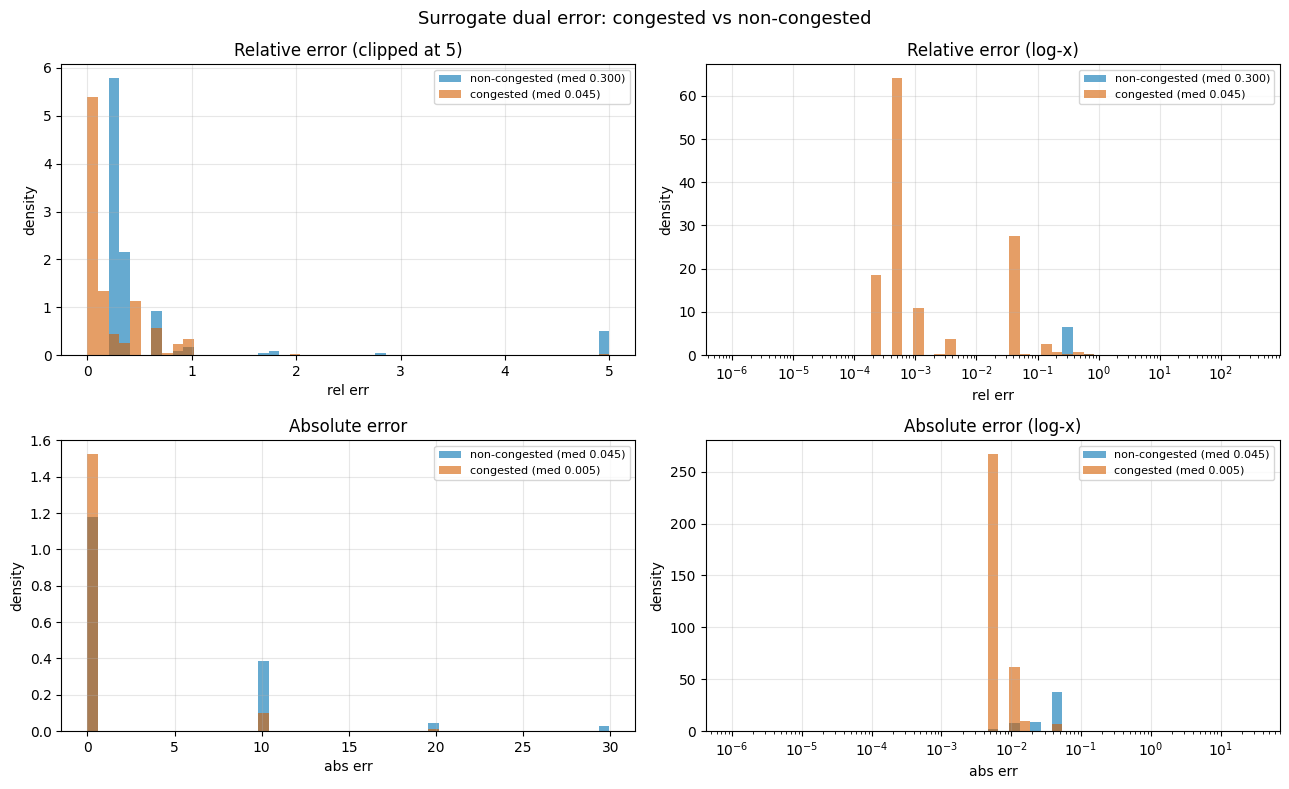

median REL err  — non-cong: 0.3  cong: 0.045
median ABS err  — non-cong: 0.045  cong: 0.005
median true|lamb| — non-cong: 0.15  cong: 0.11


In [201]:
import numpy as np, matplotlib.pyplot as plt

dual_net.eval()
with torch.no_grad():
    mu_pred, lamb_pred = dual_net(ed_gen_data.X)
lp = lamb_pred.numpy(); lt = lamb_true

rel_err = np.abs(lp - lt).sum(1) / (np.abs(lt).sum(1) + 1e-6)
abs_err = np.abs(lp - lt).sum(1)

C  = "#D55E00"   # congested
NC = "#0072B2"   # non-congested

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

def dual_hist(ax, vals, title, xlabel, logx=False, clip=None):
    v_c, v_nc = vals[congested], vals[~congested]
    if clip is not None:
        v_c  = np.clip(v_c, None, clip)
        v_nc = np.clip(v_nc, None, clip)
    if logx:
        lo = max(min(vals[vals>0].min(), 1e-6), 1e-8)
        bins = np.logspace(np.log10(lo), np.log10(vals.max()+1e-9), 50)
        ax.set_xscale("log")
    else:
        bins = np.linspace(0, (clip or vals.max()), 50)
    ax.hist(v_nc, bins=bins, alpha=0.6, color=NC, density=True,
            label=f"non-congested (med {np.median(vals[~congested]):.3f})")
    ax.hist(v_c,  bins=bins, alpha=0.6, color=C,  density=True,
            label=f"congested (med {np.median(vals[congested]):.3f})")
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel("density")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# top row: relative error (linear, and log-x to see the spread)
dual_hist(axes[0,0], rel_err, "Relative error (clipped at 5)", "rel err", clip=5)
dual_hist(axes[0,1], rel_err, "Relative error (log-x)", "rel err", logx=True)
# bottom row: absolute error (linear, and log-x)
dual_hist(axes[1,0], abs_err, "Absolute error", "abs err")
dual_hist(axes[1,1], abs_err, "Absolute error (log-x)", "abs err", logx=True)

fig.suptitle("Surrogate dual error: congested vs non-congested", fontsize=13)
fig.tight_layout(); plt.show()

# the number that resolves the artifact question:
print("median REL err  — non-cong:", round(np.median(rel_err[~congested]),3),
      " cong:", round(np.median(rel_err[congested]),3))
print("median ABS err  — non-cong:", round(np.median(abs_err[~congested]),3),
      " cong:", round(np.median(abs_err[congested]),3))
print("median true|lamb| — non-cong:", round(np.median(np.abs(lt)[~congested].sum(1)),4),
      " cong:", round(np.median(np.abs(lt)[congested].sum(1)),4))

In [203]:
# unmet-demand duals are the last 2*num_n ineq rows; but simpler: check the unmet-demand
# PRIMAL (md_n) if you have it, or the balance-dual magnitude as VOLL proxy
md_start = 2*num_g + 2*num_l           # missed-demand lower-bound dual rows
md_dual = mu[:, md_start:md_start+2*num_n]
sheds = (np.abs(md_dual) > 1e-6).any(1)      # is load being shed in this state
print("shed fraction overall:", sheds.mean())
print("rel err | shedding states:", np.median(rel_err[sheds]).round(3))
print("rel err | non-shedding:  ", np.median(rel_err[~sheds]).round(3))
# and: are the high-lamb (~30) states the shedding ones?
print("median true|lamb| shedding:", np.median(np.abs(lt)[sheds].sum(1)).round(2))

shed fraction overall: 0.9499233680522974
rel err | shedding states: 0.152
rel err | non-shedding:   0.332
median true|lamb| shedding: 0.11


In [204]:
tail = rel_err > 1.0
print(f"tail: {tail.mean():.1%} ({tail.sum()} states)")
# describe the tail vs the bulk across ALL raw features, no hypothesis:
Xn = ed_gen_data.X.numpy()
feat = np.column_stack([Xn, np.abs(lt).sum(1)])   # 9 features + true dual magnitude
names = ["D_BE","D_GE","D_FR","ec_BEL_WindOff","ec_BEL_Gas","ec_GER_Gas",
         "ec_GER_SunPV","ec_FRA_Nuclear","ec_FRA_SunPV","true|lamb|"]
import pandas as pd
df = pd.DataFrame(feat, columns=names)
df["tail"] = tail
print(df.groupby("tail").median().round(2).T)   # which features differ most in the tail?

tail: 1.8% (572 states)
tail               False     True 
D_BE             6026.01   4926.17
D_GE            47002.08  38398.18
D_FR            36462.27  28156.57
ec_BEL_WindOff     -0.00   1279.42
ec_BEL_Gas       7250.00   8750.00
ec_GER_Gas      70250.00  57875.00
ec_GER_SunPV       -0.00  34550.49
ec_FRA_Nuclear  58000.00  50000.00
ec_FRA_SunPV        0.00   1443.80
true|lamb|          0.11      0.03


## Clustering Evaluation

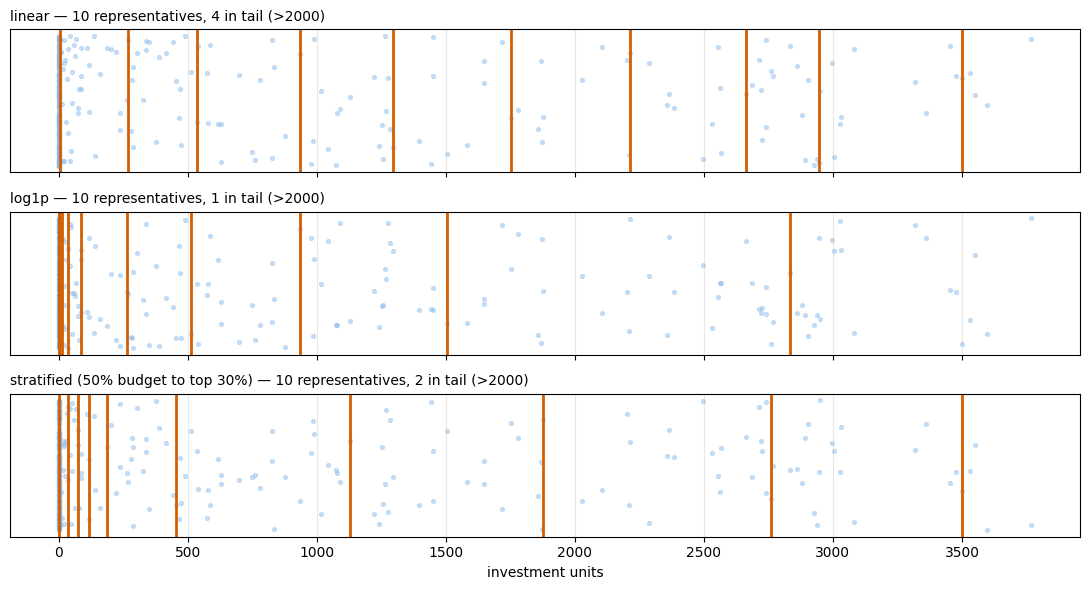

In [211]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

zero_spike = np.zeros(240)
tail = (rng.uniform(size=160)**2.0) * 4000
raw = np.sort(np.concatenate([zero_spike, tail]))

def keep_linear(vals, k):
    x = vals.reshape(-1,1)
    km = KMeans(k, n_init=10, random_state=0).fit(x)
    return [vals[np.argmin(np.abs(vals - c))] for c in km.cluster_centers_.ravel()]

def keep_log(vals, k):
    x = np.log1p(vals).reshape(-1,1)
    km = KMeans(k, n_init=10, random_state=0).fit(x)
    cen = km.cluster_centers_.ravel()
    return [vals[np.argmin(np.abs(np.log1p(vals) - c))] for c in cen]

def keep_stratified(vals, k, hi_frac=0.5, hi_pct=70):
    """Force hi_frac of the budget into the top-(100-hi_pct)% by value."""
    thr = np.percentile(vals, hi_pct)
    lo, hi = vals[vals <= thr], vals[vals > thr]
    k_hi = max(1, int(hi_frac * k)); k_lo = k - k_hi
    keep = []
    for part, kk in [(lo, k_lo), (hi, k_hi)]:
        if len(part) == 0: continue
        if len(part) <= kk: keep += list(part); continue
        km = KMeans(kk, n_init=10, random_state=0).fit(part.reshape(-1,1))
        keep += [part[np.argmin(np.abs(part - c))] for c in km.cluster_centers_.ravel()]
    return keep

k = 10
methods = [("linear", keep_linear(raw,k)),
           ("log1p", keep_log(raw,k)),
           ("stratified (50% budget to top 30%)", keep_stratified(raw,k))]

fig, axes = plt.subplots(3,1, figsize=(11,6), sharex=True)
for ax,(name,keep) in zip(axes, methods):
    ax.scatter(raw, rng.uniform(-0.3,0.3,len(raw)), s=8, alpha=0.4, color="#85B7EB")
    for v in keep:
        ax.axvline(v, color="#D55E00", lw=2)
    ax.set_title(f"{name} — {len(keep)} representatives, "
                 f"{sum(v>2000 for v in keep)} in tail (>2000)", fontsize=10, loc="left")
    ax.set_yticks([]); ax.grid(alpha=0.3, axis="x")
axes[-1].set_xlabel("investment units")
plt.tight_layout(); plt.show()

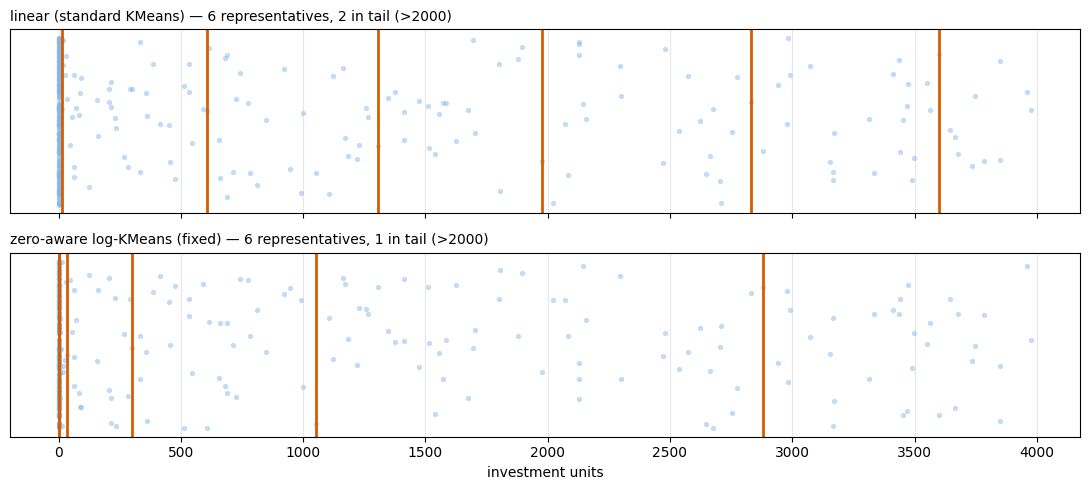

In [210]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Setup play-around dataset
rng = np.random.default_rng(0)
zero_spike = np.zeros(240)
tail = (rng.uniform(size=160)**2.0) * 4000
raw = np.sort(np.concatenate([zero_spike, tail]))

# Method A: Standard Linear Approach
def keep_linear(vals, k):
    x = vals.reshape(-1,1)
    km = KMeans(k, n_init=10, random_state=0).fit(x)
    return [vals[np.argmin(np.abs(vals - c))] for c in km.cluster_centers_.ravel()]

# Method B: Zero-Aware Log-KMeans (The correct way)
def keep_zero_aware_log(vals, k):
    zeros = vals[vals == 0]
    positives = vals[vals > 0]
    keep = []
    
    # 1. Lock down exactly one cluster for the 0 entries
    if len(zeros) > 0:
        keep.append(0.0)
        clusters_left = k - 1
    else:
        clusters_left = k
        
    if len(positives) == 0:
        return keep

    # 2. Transform the positive numbers to spread them out evenly
    log_positives = np.log1p(positives).reshape(-1, 1)
    
    # 3. Cluster in the log space
    km = KMeans(clusters_left, n_init=10, random_state=0).fit(log_positives)
    
    # 4. Map the centers back to the original values
    for c in km.cluster_centers_.ravel():
        closest_idx = np.argmin(np.abs(np.log1p(positives) - c))
        keep.append(positives[closest_idx])
        
    return sorted(list(set(keep)))

# Run both configurations
k = 6
linear_representatives = keep_linear(raw, k)
zero_log_representatives = keep_zero_aware_log(raw, k)

# 2. Build the comparison plot
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
methods_to_plot = [
    ("linear (standard KMeans)", linear_representatives),
    ("zero-aware log-KMeans (fixed)", zero_log_representatives)
]

for ax, (name, keep) in zip(axes, methods_to_plot):
    ax.scatter(raw, rng.uniform(-0.3, 0.3, len(raw)), s=8, alpha=0.4, color="#85B7EB")
    
    for v in keep:
        ax.axvline(v, color="#D55E00", lw=2)
        
    ax.set_title(f"{name} — {len(keep)} representatives, "
                 f"{sum(v>2000 for v in keep)} in tail (>2000)", fontsize=10, loc="left")
    ax.set_yticks([])
    ax.grid(alpha=0.3, axis="x")

axes[-1].set_xlabel("investment units")
plt.tight_layout()
plt.show()
